In [3]:
import os
os.environ["DDE_BACKEND"]="pytorch"

In [4]:
import numpy as np 
import torch

In [5]:
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def derivatives(y, x):
    dy = torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y = torch.autograd.grad(dy, x, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    d3y = torch.autograd.grad(d2y, x, grad_outputs=torch.ones_like(d2y), create_graph=True)[0]
    d4y = torch.autograd.grad(d3y, x, grad_outputs=torch.ones_like(d3y), create_graph=True)[0]
    return dy, d2y, d3y, d4y

In [7]:
def physics_loss(model, x, EI):
    x.requires_grad_(True)
    y = model(x)

    _, _, _, d4y = derivatives(y, x)

    q = -10  # UniformLoad
    loss = torch.mean((d4y - q/EI)**2)

    return loss

In [8]:
model=PINN()

x_test = torch.linspace(0, 1, 100).reshape(-1,1)
y_pred = model(x_test)

In [9]:
def boundary_loss(model, EI):
    x0 = torch.tensor([[0.0]], requires_grad=True)
    xL = torch.tensor([[1.0]], requires_grad=True)

    y0 = model(x0)
    yL = model(xL)

    _, d2y0, _, _ = derivatives(y0, x0)
    _, d2yL, _, _ = derivatives(yL, xL)

    loss = y0**2 + yL**2 + d2y0**2 + d2yL**2
    return loss
  

In [10]:
def total_loss(model, x, EI):
    return physics_loss(model, x, EI) + 1000 * boundary_loss(model, EI)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

EI = 1.0
loss_history =[]

for epoch in range(10000):
    x = torch.rand(100, 1)  

    loss = total_loss(model, x, EI)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch % 1000 == 0:
        print(epoch, loss.item())

0 200.55960083007812
1000 96.46570587158203
2000 90.03547668457031
3000 81.77201843261719
4000 68.88929748535156
5000 42.712982177734375
6000 35.68037796020508
7000 8.17563247680664
8000 5.388626575469971
9000 3.654766798019409


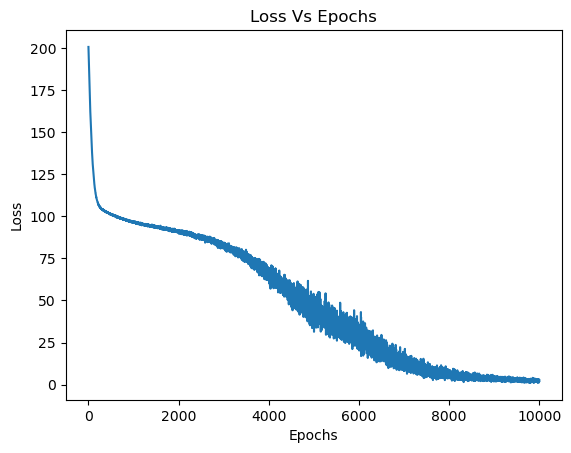

In [12]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Vs Epochs")
plt.show()

In [13]:
x_test = torch.linspace(0, 1, 100).reshape(-1,1)
x_test.requires_grad_(True)

y = model(x_test)

dy, d2y, d3y, d4y = derivatives(y, x_test)

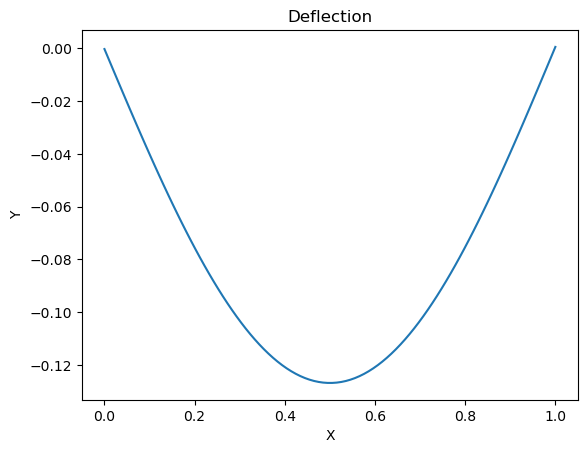

In [14]:
plt.plot(x_test.cpu().detach().numpy(), y.cpu().detach().numpy())
plt.title("Deflection")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
M= -EI * d2y

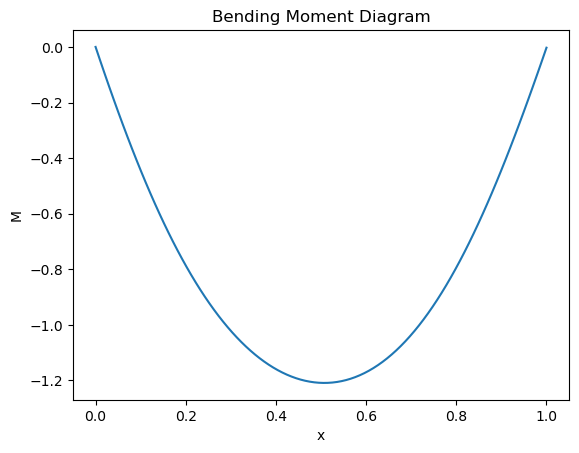

In [16]:
plt.plot(x_test.cpu().detach().numpy(), M.cpu().detach().numpy())
plt.title("Bending Moment Diagram")
plt.xlabel("x")
plt.ylabel("M")
plt.show()